# PointNet for RadHAR
Adapted to the raw GitHub dataset format with per-point features `[x, y, z, range, velocity, doppler_bin, bearing, intensity]` and activity labels from the class folders.

we write the dimensions as such:
- T the amounf of time frames (30 frames per second)
- D the amount of features (8 features: x, y, z, range, velocity, doppler_bin, bearing and intensity)
- N the amounf of point per frame (set to 32)
- B the amounf of batches

Amongts the N dimension, theres invariance by permutation because poibt order doesn tmatter. To agcieve this token permuation invariance, the Max Pooling is added. 

In [1]:
from datetime import datetime
from functools import lru_cache
from pathlib import Path
import time
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from IPython.display import clear_output

In [ ]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'RadHAR'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'radHAR_pointnetV1'
TRAIN_SPLIT_ROOT = DATA_ROOT / 'Train'
TEST_SPLIT_ROOT = DATA_ROOT / 'Test'

ACTIVITY_CLASS_NAMES = ('boxing', 'jack', 'jump', 'squats', 'walk')

SEEDS = [1234]
DEVICE = "mps"
CONFIG = {
    'feature_names': ('x', 'y', 'z', 'range', 'velocity', 'doppler_bin', 'bearing', 'intensity'),
    'feature_amount': 8,
    'frame_count': 60,   # amount of frames per window (time dimension)
    'frame_stride': 60,  # time offset between two windows
    'points_per_frame': 32,   # constant amount of points per frame for tensor shapes
    'validation_fraction': 0.1,
    'clipping': 4.0, # outliers explode the validation losses, which prevents from evaluating the model
    'batch_size': 24,
    'dropout_rate': 0.3,
    'smoothing': 0.1,  # label smoothing for generalization
    "num_epochs": 40,
    "base_lr": 1.5e-3,
    "adam_momentum": 0.8,
    "weight_decay": 1e-4,  # prevents weights from drifting up and up forever
    "lr_decay_samples": 200000,  # smooth decay counted in samples
    "lr_decay_gamma": 0.8, # divided by gamma every N samples
}

In [3]:
CONFIG.update({
    'feature_names': ('x', 'y', 'z','velocity'),
    'feature_amount': 4
})

# Data processing

In [4]:
def build_window_index(file_paths):
    "Create raw frame windows from a split folder or a list of files."
    tracked_keys = {'point_id', *CONFIG['feature_names']}
    paths = [path for class_name in ACTIVITY_CLASS_NAMES for path in sorted((Path(file_paths) / class_name).glob('*.txt'))] if isinstance(file_paths, (str, Path)) and Path(file_paths).is_dir() else [Path(path) for path in file_paths]
    samples = []
    for file_path in paths:
        frames, frame, point = [], [], {}
        for raw_line in file_path.read_text().splitlines():
            line = raw_line.strip()
            if line == '---':
                if int(point.get('point_id', -1)) == 0 and frame:
                    frames.append(torch.tensor(frame, dtype=torch.float32)); frame = []
                frame.append([float(point.get(name, 0.0)) for name in CONFIG['feature_names']])
                point = {}
            elif ':' in line:
                key, raw_value = line.split(':', 1)
                if key.strip() in tracked_keys: point[key.strip()] = float(raw_value)
        if point: frame.append([float(point.get(name, 0.0)) for name in CONFIG['feature_names']])
        if frame: frames.append(torch.tensor(frame, dtype=torch.float32))
        for start_idx in range(0, len(frames) - CONFIG['frame_count'] + 1, CONFIG['frame_stride']):
            samples.append((frames, start_idx, ACTIVITY_CLASS_NAMES.index(file_path.parent.name)))
    return samples

In [5]:
@lru_cache(maxsize=None)
def validation_split():
    "Split the training files into train and validation sets at the file level." 
    train_files = []
    val_files = []
    for class_name in ACTIVITY_CLASS_NAMES:
        file_paths = sorted((TRAIN_SPLIT_ROOT / class_name).glob('*.txt'))
        val_count = max(1, int(len(file_paths) * CONFIG['validation_fraction']))
        val_count = min(val_count, len(file_paths) - 1)
        train_files.extend(str(path) for path in file_paths[:-val_count])
        val_files.extend(str(path) for path in file_paths[-val_count:])
    return train_files, val_files

In [6]:
@lru_cache(maxsize=None)
def statistics():
    "Compute normalization stats over the train subset only."
    train_files, _ = validation_split()
    seen, all_points = set(), []
    for frames, _, _ in build_window_index(train_files):
        if id(frames) not in seen:
            all_points.append(torch.cat(frames, dim=0)); seen.add(id(frames))
    all_points = torch.cat(all_points, dim=0)
    mean = all_points.mean(dim=0)
    std = all_points.std(dim=0).clamp_min(1e-6)
    return mean, std

In [7]:
def process_frame(points):
    "Normalize and keep the same point slots in order, padding with zeros if needed."
    mean, std = statistics()
    points = ((torch.as_tensor(points, dtype=torch.float32) - mean) / std).clamp(-CONFIG['clipping'], CONFIG['clipping'])
    if len(points) >= CONFIG['points_per_frame']:
        return points[:CONFIG['points_per_frame']]
    padded = torch.zeros((CONFIG['points_per_frame'], CONFIG['feature_amount']), dtype=torch.float32)
    padded[:len(points)] = points
    return padded

In [8]:
def augmentation(window):
    "Apply spatial augmentation across a training window (same transformation for whole window)."
    scale = torch.empty(3).uniform_(0.5, 1.5)
    shift = torch.empty(3).uniform_(-0.5, 0.5)
    augmented = []
    for frame in window:
        frame = frame.clone()
        jitter = torch.randn_like(frame[:, :3]) * 0.01
        frame[:, :3] = frame[:, :3] * scale + shift + jitter
        augmented.append(frame[torch.randperm(len(frame))])
    return augmented

In [9]:
class RadHARDataset(Dataset):
    "Dataset, conatining the frames"
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frames, start_idx, label_idx = self.samples[idx]
        window = [process_frame(frame) for frame in frames[start_idx:start_idx + CONFIG['frame_count']]]
        if self.augment:
            window = augmentation(window)
        sequence = torch.stack(window, dim=0)
        label = torch.tensor(label_idx, dtype=torch.long)
        return sequence, label

In [10]:
sample_file = next((DATA_ROOT / "Train").rglob("*.txt"))
frames = build_window_index([sample_file])[0][0]
print('Sample file:', sample_file)
print('Raw frames:', len(frames))
print('Raw frame shape:', frames[0].shape) # (points_per_frame, feature_amount)

train_files, valid_files = validation_split()
train_windows = build_window_index(train_files)
valid_windows = build_window_index(valid_files)
print('Train windows:', len(train_windows))
print('Validation windows:', len(valid_windows))
print('Example windows:', [(len(frames), start_idx, label_idx) for frames, start_idx, label_idx in train_windows[:2]])

processed_frame = process_frame(frames[0])
print('Processed frame shape:', processed_frame.shape)

train_data = RadHARDataset(train_windows, augment=True)
print('Dataset size:', len(train_data))
x, y = train_data[0]
print('Sequence shape:', x.shape)
print('Label:', y)

Sample file: /Users/elo/Coding/radar/datasets/RadHAR/Train/walk/___walk_20_7.txt
Raw frames: 601
Raw frame shape: torch.Size([21, 4])
Train windows: 2028
Validation windows: 109
Example windows: [(601, 0, 0), (601, 60, 0)]
Processed frame shape: torch.Size([32, 4])
Dataset size: 2028
Sequence shape: torch.Size([60, 32, 4])
Label: tensor(0)


# architecture

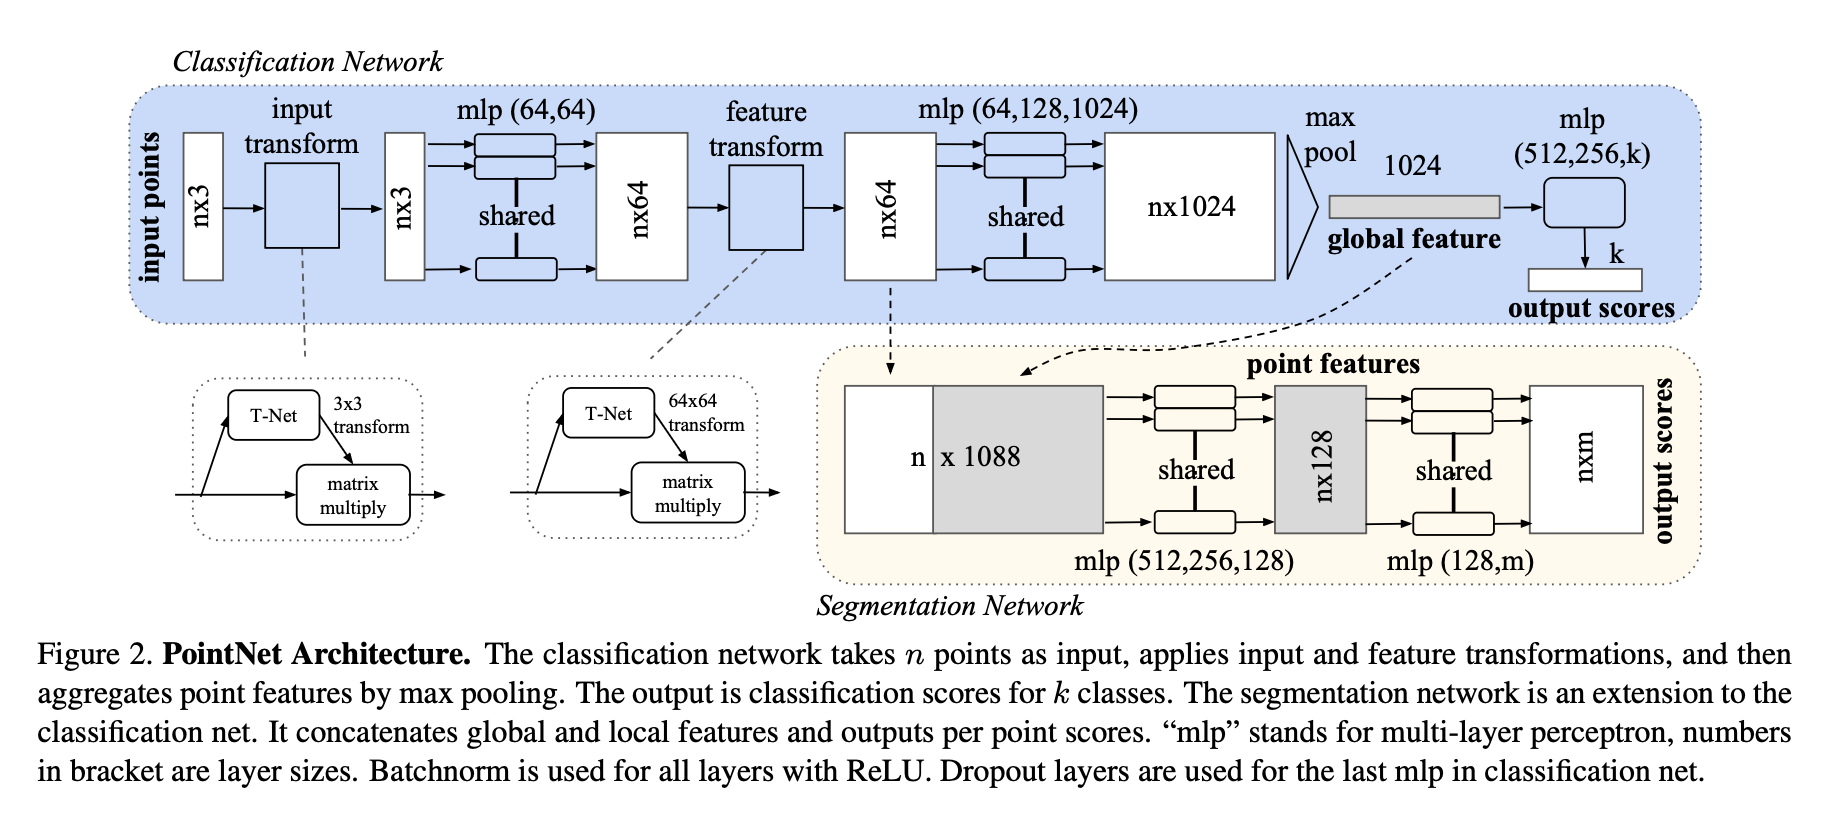

In [11]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

In [12]:
class PointBatchNorm(nn.Module):
    "Normalization stats are over batch, frames and points dim."
    def __init__(self, feature_dim):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_dim, eps=1e-3, momentum=0.5)

    def forward(self, x):
        if x.dim() == 2: # after the maxpooling, the frame and point dimensions disappear
            return self.norm(x)

        batch_size, frame_count, point_count, feature_dim = x.shape
        x = x.reshape(batch_size * frame_count * point_count, feature_dim)
        x = self.norm(x)
        return x.view(batch_size, frame_count, point_count, feature_dim)

In [13]:
class TNet(nn.Module):
    """Layer inside the transform layers. Outputs a D*D matrix to multiply the input.``
    This is meant to rotate+scale the points to make it size/rotation invariant.
    Invertible matrix with the loss penalties.
    """
    def __init__(self, feature_dim):
        super().__init__()
        self.feature_dim = feature_dim
        self.ff1 = nn.Linear(feature_dim, 64)
        self.norm1 = PointBatchNorm(64)
        self.ff2 = nn.Linear(64, 128)
        self.norm2 = PointBatchNorm(128)
        self.ff3 = nn.Linear(128, 1024)
        self.norm3 = PointBatchNorm(1024)
        self.ff4 = nn.Linear(1024, 512)
        self.norm4 = PointBatchNorm(512)
        self.ff5 = nn.Linear(512, 256)
        self.norm5 = PointBatchNorm(256)
        self.ff6 = nn.Linear(256, feature_dim * feature_dim)
        xavier_init(self)
        nn.init.zeros_(self.ff6.weight)
        nn.init.zeros_(self.ff6.bias)

    def forward(self, x):
        # x : (B, T, N, D)
        batch_size, frame_count, _, _ = x.shape
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = F.relu(self.norm3(self.ff3(x)))
        x = torch.max(x, dim=2)[0].unsqueeze(2) # max-reduction over N, keeps one point per feature
        x = F.relu(self.norm4(self.ff4(x)))
        x = F.relu(self.norm5(self.ff5(x)))
        x = self.ff6(x)  # last layer isn't normalized nor activated
        mat = x.view(batch_size, frame_count, self.feature_dim, self.feature_dim) # (B, T, D, D)
        eye = torch.eye(self.feature_dim, device=x.device).repeat(batch_size, frame_count, 1, 1)
        # T identity matrices, shape: (B, T, D, D)
        return mat + eye

In [14]:
class EncoderBlock(nn.Module):
    """Block of the main architecture contaning a TNet tranformed
    followed by a shared mlp (a size 1 kernel convolution).
    The shared property make it oblivious to point position in the sequence"""

    def __init__(self, input_feature, mlp_dims):
        super().__init__()
        self.tnet = TNet(feature_dim=input_feature)
        self.mlp_layers = nn.ModuleList()
        self.mlp_norms = nn.ModuleList()
        for in_dim, out_dim in zip(mlp_dims[:-1], mlp_dims[1:]):
            self.mlp_layers.append(nn.Linear(in_dim, out_dim))
            self.mlp_norms.append(PointBatchNorm(out_dim))
        xavier_init(self.mlp_layers)

    def forward(self, x):
        # x: (B, T, N, D)
        self.TNet_matrix = self.tnet(x) # (B, T, D, D)
        x = x @ self.TNet_matrix # transform layer mutiplying the input by TNet matrix
        for linear, norm in zip(self.mlp_layers, self.mlp_norms):
            x = F.relu(norm(linear(x)))
        return x

In [15]:
class Generator(nn.Module):
    "Compute logits from the global features."
    def __init__(self, class_amount, dropout_rate):
        super().__init__()
        self.ff1 = nn.Linear(1024, 512, bias=False)
        self.norm1 = PointBatchNorm(512)
        self.ff2 = nn.Linear(512, 256, bias=False)
        self.norm2 = PointBatchNorm(256)
        self.ff3 = nn.Linear(256, class_amount)
        self.dropout = nn.Dropout(dropout_rate)
        xavier_init(self)

    def forward(self, x):
        # x: (B, 1024)
        x = F.relu(self.norm1(self.ff1(x)))
        x = self.dropout(x)
        x = F.relu(self.norm2(self.ff2(x)))
        x = self.dropout(x)
        return self.ff3(x)

In [16]:
class PointNet(nn.Module):
    "The whole architecture"
    def __init__(self, feature_dim):
        super().__init__()
        self.block1 = EncoderBlock(feature_dim, [feature_dim, 64, 64])
        self.block2 = EncoderBlock(64, [64, 64, 128, 1024])
        self.generator = Generator(len(ACTIVITY_CLASS_NAMES), CONFIG['dropout_rate'])

    def forward(self, x):
        # x: (B, T, N, D)
        batch_size, frame_count, _, _ = x.shape
        x = self.block1(x) # x: (B, T, N, 64)
        x = self.block2(x) # x: (B, T, N, 1024)
        x = torch.max(x, dim=2)[0]  # maxpool over N
        x = x.view(batch_size, frame_count, 1024).mean(dim=1) # average over T
        return self.generator(x) # logits

In [17]:
model = PointNet(CONFIG["feature_amount"])

train_dataset = RadHARDataset(train_windows, augment=True)
train_dataloader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
sample_batch, sample_labels = next(iter(train_dataloader))
print(f'Input shape: {sample_batch.shape}') # x: (B, T, N, D)
print(f'Label shape: {sample_labels.shape}') 
output = model(sample_batch)
print(f'Output shape: {output.shape}')

Input shape: torch.Size([24, 60, 32, 4])
Label shape: torch.Size([24])
Output shape: torch.Size([24, 5])


# training

In [18]:
def create_dataloaders(batch_size, seed):
    "Create train and validation dataloaders."
    train_files, valid_files = validation_split()
    train_samples = build_window_index(train_files)
    valid_samples = build_window_index(valid_files)
    train_dataset = RadHARDataset(train_samples, augment=True)
    valid_dataset = RadHARDataset(valid_samples)
    generator = torch.Generator().manual_seed(seed)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, generator=generator)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    return train_dataloader, valid_dataloader

In [19]:
def rate(sample_count, base):
    "Exponential LR decay, scaling by gamma every configured number of samples."
    decay = sample_count / CONFIG["lr_decay_samples"]
    return base * CONFIG["lr_decay_gamma"] ** decay

In [20]:
def batch_norm_decay(model, sample_count):
    "BN momentum decay schedule."
    momentum = max(0.01, 0.5 * 0.5 ** (sample_count / CONFIG["lr_decay_samples"])) # same rate as the LR decay
    for module in model.modules():
        if isinstance(module, nn.BatchNorm1d): module.momentum = momentum

In [21]:
def smoothing(pred, targets, smoothing=0):
    "The true class becomes 1-smoothing, and the rest of the probability is distributed amongst the other classes"
    class_amount = pred.size(1) # (B, C)
    one_hot = torch.zeros_like(pred).scatter(1, targets.unsqueeze(1), 1) # (B, C)
    soft_ones = one_hot * (1 - smoothing) + (1 - one_hot) * smoothing / (class_amount - 1)
    log_prob = F.log_softmax(pred, dim=1) # log of probabilities
    return -(soft_ones * log_prob).sum(dim=1).mean() # cross-entropy, then averaged over batches

In [22]:
def orthogonal(matrix):
    "Penalty term to make the TNet matrices more orthogonal."
    feature_dim = matrix.shape[-1]
    eye = torch.eye(feature_dim, device=matrix.device)
    diff = eye - matrix @ matrix.transpose(-1, -2)
    return diff.pow(2).sum(dim=(-1, -2)).mean()

In [23]:
class Loss:
    "Cross-entropy loss with smoothing. Regulation on the TNet matrices to make them orthogonal."
    def __init__(self, model, reg_coeff=0.01):
        self.model = model
        self.reg_coeff = reg_coeff

    def __call__(self, out, targets):
        loss = smoothing(out, targets, CONFIG['smoothing'])
        reg = self.reg_coeff * orthogonal(self.model.block2.TNet_matrix)
        return loss + reg

In [24]:
def run_epoch(data_iter, model, loss_compute, optimizers, mode="train", seen_samples=0):
    "Runs one epoch, either for training, either validation."
    start, device = time.time(), torch.device(DEVICE)
    loss_list, grad_norms, learning_rates, logit_maxes, weight_maxes, bias_maxes, sample_rates = [], [], [], [], [], [], []

    for i, (src, targets) in enumerate(data_iter):
        src, targets = src.to(device), targets.to(device)
        ntokens = targets.size(0)
        if mode == "train": batch_norm_decay(model, seen_samples)
        logits = model(src); loss = loss_compute(logits, targets)

        if mode == "train":
            lr = rate(seen_samples, CONFIG["base_lr"])
            for optimizer in optimizers:
                for param_group in optimizer.param_groups: param_group["lr"] = lr
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf")) # computes gradient norm
            for optimizer in optimizers: optimizer.step(); optimizer.zero_grad(set_to_none=True)
            batch_loss, norm, logit_max, weight_max, bias_max = torch.stack((loss.detach(), norm, logits.detach().abs().max(),
                torch.stack([parameter.detach().abs().max() for name, parameter in model.named_parameters() if name.endswith("weight")]).max(),
                torch.stack([parameter.detach().abs().max() for name, parameter in model.named_parameters() if name.endswith("bias")]).max())).cpu().tolist()
            grad_norms.append(norm); learning_rates.append(lr); logit_maxes.append(logit_max); weight_maxes.append(weight_max); bias_maxes.append(bias_max)
            seen_samples += ntokens
            sample_rate = ntokens / (time.time() - start); sample_rates.append(sample_rate)
            print(f"Batch: {i:6d} | Loss: {batch_loss:6.2f} | Samples/sec: {sample_rate:7.1f} | Learn. Rate: {lr:6.1e}")
            start = time.time()
        loss_list.append(batch_loss if mode == "train" else loss.item())

    return loss_list, grad_norms, learning_rates, logit_maxes, weight_maxes, bias_maxes, sample_rates, seen_samples

In [25]:
def plot(train_losses, valid_losses, grad_norms, learning_rates, logit_maxes, weight_maxes, bias_maxes, model_param_count, num_epochs, train_epoch_sizes, train_batch_sizes, valid_epoch_sizes, epoch_means):
    "Plot losses, gradient norms, maximum logits, weights, and biases."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    has_validation = bool(valid_losses)
    tick_step = max(1, (num_epochs + 19) // 20)
    epoch_ticks = list(range(0, num_epochs + 1, tick_step))
    if epoch_ticks[-1] != num_epochs: epoch_ticks.append(num_epochs)
    fig, axes = plt.subplots(4, 1, figsize=(10, 20))
    ax1 = axes[0]
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    ax1.plot(x_train, train_losses, label="Training Loss")
    ax1.plot(x_train, train_loss_rolling, label="Train. Loss (Avg)", color="darkblue", linewidth=1)
    ax1.set(ylabel="Loss", title="Training Loss per batch")
    loss_values = pd.Series(train_losses).dropna()
    if has_validation:
        x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
        epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
        ax1.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7)
        ax1.plot(x_valid, epoch_mean_valid_losses, label="Valid. Loss (Avg)", color="red", linewidth=1, linestyle="--")
        ax1.set_title("Training and Validation Loss per batch")
        loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    if has_validation:
        y_min, y_max = ax1.get_ylim()
        best_mean_val = float("inf")
        for i, mean_val in enumerate(epoch_means):
            if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
            best_mean_val = min(best_mean_val, mean_val)
    diagnostics = ((grad_norms, "Gradient Norm", "orange", "Norm", "Gradient Norm and Learning Rate per batch"),
        (logit_maxes, "Max |Logit|", "purple", "Max |Logit|", "Maximum Logit per Batch"),
        (weight_maxes, "Max |Weight|", "green", "Max |Value|", "Maximum Weight and Bias per Batch"))
    for ax, (values, label, color, ylabel, title) in zip(axes[1:], diagnostics):
        ax.plot(x_train, values, label=label, color=color); ax.set(ylabel=ylabel, title=title)
    lr_ax = axes[1].twinx()
    lr_ax.plot(x_train, learning_rates, label="Learning Rate", color="darkgreen")
    lr_ax.set_ylabel("Learning Rate", color="black"); lr_ax.tick_params(axis="y", labelcolor="black")
    lr_ax.set_ylim(bottom=0)
    lr_ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False); lr_ax.locator_params(axis="y", nbins=5)
    axes[3].plot(x_train, bias_maxes, label="Max |Bias|", color="blue")
    grad_values = pd.Series(grad_norms).dropna()
    top = min(grad_values.max(), 30 * grad_values.min())
    axes[1].set_ylim(0, top + 1e-6)
    for ax in axes:
        ax.set(xlim=(0, num_epochs), xlabel="Epochs"); ax.set_xticks(epoch_ticks)
        ax.set_xticks([], minor=True); ax.legend()
    lines = axes[1].lines + lr_ax.lines
    axes[1].legend(lines, [line.get_label() for line in lines], loc="upper right")
    axes[1].text(0.99, 0.80, f"Params count: {model_param_count:,}\nBatch size: {train_batch_sizes[0]} → {train_batch_sizes[-1]}", transform=axes[1].transAxes, ha="right", va="top", fontsize=9, color="dimgray")
    fig.subplots_adjust(hspace=0.35); plt.show(); return fig

In [26]:
def save_results(seed, model_param_count, num_epochs, train_losses, epoch_means, sample_rates, training_seconds, fig):
    "Save the plots and training metadata per seed in a markdown."
    completed = datetime.now().astimezone()
    result_dir = PROJECT_ROOT / "results" / "radHAR" / completed.strftime("%Y-%m-%d")
    image_dir = result_dir / "image"; image_dir.mkdir(parents=True, exist_ok=True)
    run_name = f"seed_{seed}_{completed:%H%M%S}"
    plot_path, report_path = image_dir / f"{run_name}.png", result_dir / f"{run_name}.md"
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    metadata = {
        "Seed": seed, "Epochs": num_epochs, "Validation fraction": CONFIG["validation_fraction"],
        "Batch size": f"{CONFIG['batch_size']} → {CONFIG['batch_size'] + num_epochs - 1}",
        "Dropout rate": CONFIG["dropout_rate"], "Label smoothing": CONFIG["smoothing"],
        "Base learning rate": f"{CONFIG['base_lr']:.1e}", "LR decay samples": f"{CONFIG['lr_decay_samples']:,}",
        "LR gamma": CONFIG["lr_decay_gamma"], "BNorm decay": "0.5 → 0.01", "Weight decay": f"{CONFIG['weight_decay']:.1e}",
        "Lowest training batch loss": f"{min(train_losses):.6f}"}

    if epoch_means:
        best_epoch = min(range(len(epoch_means)), key=epoch_means.__getitem__)
        metadata["Lowest mean validation loss"] = f"{epoch_means[best_epoch]:.6f}"
        metadata["Best validation epoch"] = best_epoch
    metadata.update({"Parameters": f"{model_param_count:,}", "Average samples/sec": f"{sum(sample_rates) / len(sample_rates):.1f}", "Total training time": time.strftime("%H:%M:%S", time.gmtime(training_seconds)), "Completed": completed.isoformat(timespec="seconds")})
    rows = "\n".join(f"| {key} | {value} |" for key, value in metadata.items())
    report_path.write_text(f"# PointNet RadHAR — seed {seed}\n\n![Training plot](image/{plot_path.name})\n\n| Metadata | Value |\n|---|---|\n{rows}\n", encoding="utf-8")

In [27]:
def train_model(seed, num_epochs):
    "Training process of the model for a seed."
    training_start = time.time()
    torch.manual_seed(seed)
    print(f"Training process starting for seed {seed}...", flush=True)
    model = PointNet(CONFIG["feature_amount"]).to(torch.device(DEVICE))
    model_param_count = sum(p.numel() for p in model.parameters())
    train_dataloader, valid_dataloader = create_dataloaders(CONFIG["batch_size"], seed)
    train_dataset, generator = train_dataloader.dataset, train_dataloader.generator
    tnet_output_matrix = model.block2.tnet.ff6.weight
    matrix_params = [parameter for parameter in model.parameters() if parameter.ndim == 2 and parameter is not tnet_output_matrix]
    other_params = [parameter for parameter in model.parameters() if parameter.ndim != 2] + [tnet_output_matrix]
    optimizers = (torch.optim.Muon(matrix_params, lr=rate(0, CONFIG["base_lr"]), momentum=0.95, weight_decay=CONFIG["weight_decay"], adjust_lr_fn="match_rms_adamw"),
                  torch.optim.Adam(other_params, lr=rate(0, CONFIG["base_lr"]), betas=(CONFIG["adam_momentum"], 0.999), weight_decay=CONFIG["weight_decay"]))

    train_losses, valid_losses, grad_norms, learning_rates, logit_maxes, weight_maxes, bias_maxes, sample_rates = [], [], [], [], [], [], [], []
    train_epoch_sizes, train_batch_sizes, valid_epoch_sizes, epoch_means, seen_samples = [], [], [], [], 0
    loss_compute, checkpoint_dir = Loss(model), CHECKPOINT_ROOT / f"seed_{seed}"
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        current_batch_size = CONFIG["batch_size"] + epoch
        train_dataloader = DataLoader(train_dataset, batch_size=current_batch_size, shuffle=True, drop_last=True, generator=generator)
        train_batch_sizes.append(current_batch_size)
        model.train(); print(f"Epoch n°{epoch} Training — batch size {current_batch_size} ====", flush=True)
        loss_list, batch_grad_norms, batch_learning_rates, batch_logit_maxes, batch_weight_maxes, batch_bias_maxes, batch_sample_rates, seen_samples = run_epoch(train_dataloader, model, loss_compute, optimizers, mode="train", seen_samples=seen_samples)
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); grad_norms.extend(batch_grad_norms); learning_rates.extend(batch_learning_rates); logit_maxes.extend(batch_logit_maxes); weight_maxes.extend(batch_weight_maxes); bias_maxes.extend(batch_bias_maxes); sample_rates.extend(batch_sample_rates)
        if epoch == 0:
            for checkpoint in checkpoint_dir.glob("checkpoint_*.pt"): checkpoint.unlink()
        torch.save(model.state_dict(), checkpoint_dir / f"checkpoint_{epoch:02d}.pt")
        clear_output(wait=True)
        print(f"Training process starting for seed {seed}...", flush=True)
        if len(valid_dataloader) > 0:
            print(f"Epoch n°{epoch} Validation ====", flush=True); model.eval()
            with torch.no_grad():
                loss_list, _, _, _, _, _, _, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
            valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))
            mean_val = sum(loss_list) / len(loss_list); epoch_means.append(mean_val)
            print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        fig = plot(train_losses, valid_losses, grad_norms, learning_rates, logit_maxes, weight_maxes, bias_maxes, model_param_count, num_epochs, train_epoch_sizes, train_batch_sizes, valid_epoch_sizes, epoch_means)
    save_results(seed, model_param_count, num_epochs, train_losses, epoch_means, sample_rates, time.time() - training_start, fig)

Training process starting for seed 1234...
Epoch n°39 Validation ====
Epoch n°39 complete | Validation loss: 0.4875


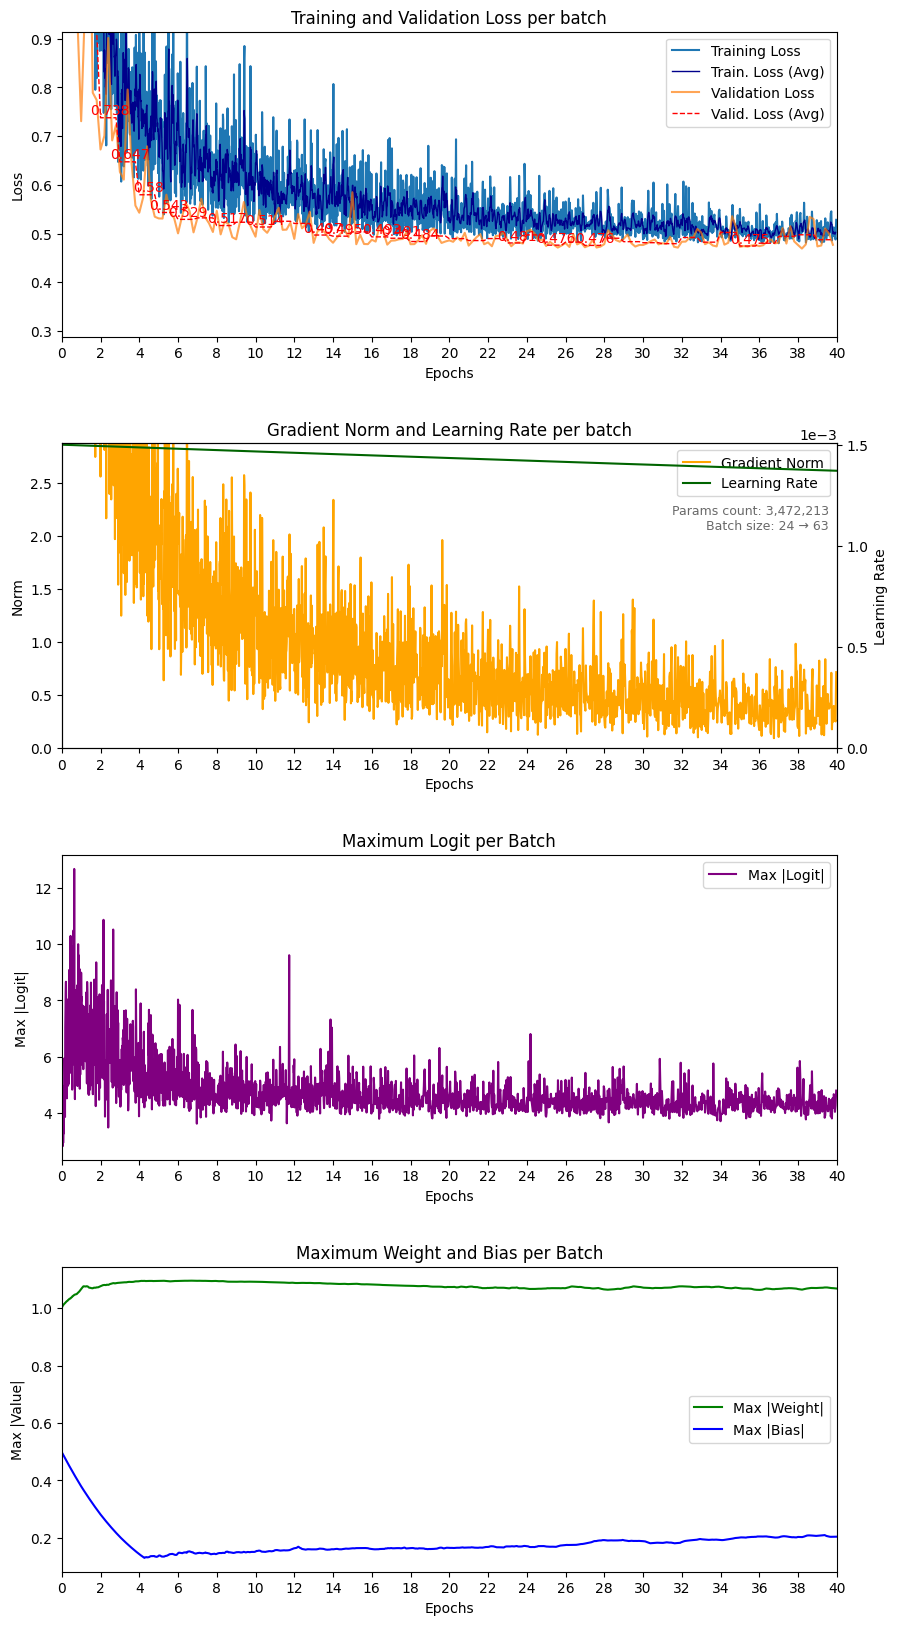

In [28]:
if __name__ == "__main__":
    for seed in SEEDS:
        train_model(seed, CONFIG['num_epochs'])

# inference/evaluation

In [29]:
def compute_f1(predictions, labels):
    "Compute the per-class F1 scores."
    scores = []
    for class_idx in range(len(ACTIVITY_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return scores

In [30]:
def evaluate_validation(epoch, seed):
    "Score a checkpoint on validation set (accuracy + F1) for a given seed."
    checkpoint_path = CHECKPOINT_ROOT / f"seed_{seed}" / f"checkpoint_{epoch:02d}.pt"
    device = torch.device(DEVICE)
    model = PointNet(CONFIG['feature_amount']).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)); model.eval()
    _, valid_files = validation_split()
    eval_samples = build_window_index(valid_files)
    eval_loader = DataLoader(RadHARDataset(eval_samples), batch_size=CONFIG['batch_size'], shuffle=False)

    predictions, true_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            true_labels.append(labels)

    predictions, labels = torch.cat(predictions), torch.cat(true_labels)
    per_class_f1 = compute_f1(predictions, labels)
    accuracy = (predictions == labels).float().mean().item()
    return sum(per_class_f1) / len(per_class_f1), accuracy

In [31]:
def plot_validation_metrics(seed):
    "Plot validation accuracy and F1 for every checkpoint."
    checkpoint_id = lambda path: int(path.stem.split("_")[-1])
    checkpoint_paths = sorted((CHECKPOINT_ROOT / f"seed_{seed}").glob("checkpoint_*.pt"), key=checkpoint_id)
    checkpoint_numbers = [checkpoint_id(path) for path in checkpoint_paths]
    metrics = [evaluate_validation(checkpoint, seed) for checkpoint in checkpoint_numbers]
    macro_f1_scores, accuracy_scores = zip(*metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    lines = [ax.plot(checkpoint_numbers, scores, marker="o", label=label)[0] for scores, label in ((macro_f1_scores, "Macro F1"), (accuracy_scores, "Accuracy"))]
    for scores, line, offset in zip((macro_f1_scores, accuracy_scores), lines, (0.02, 0.05)):
        best = -1
        for checkpoint, score in zip(checkpoint_numbers, scores):
            if score > best:
                ax.text(checkpoint, score + offset, f"{score:.3f}", ha="center", color=line.get_color())
                best = score

    tick_step = 1 if len(checkpoint_paths) <= 20 else max(2, (len(checkpoint_paths) + 14) // 15)
    tick_indices = list(range(0, len(checkpoint_paths), tick_step))
    ax.set_xticks([checkpoint_numbers[i] for i in tick_indices],
                  [checkpoint_paths[i].stem for i in tick_indices], rotation=45, ha="right")
    ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5)
    ax.set_ylim(min(macro_f1_scores + accuracy_scores) - 0.02, 1)
    ax.set(xlabel="Checkpoint", ylabel="Score", title="Validation checkpoint performance")
    ax.legend(); fig.tight_layout(); plt.show()
    best_checkpoint = checkpoint_numbers[accuracy_scores.index(max(accuracy_scores))]
    print(f'Seed {seed} best accuracy checkpoint: {best_checkpoint}')
    return best_checkpoint

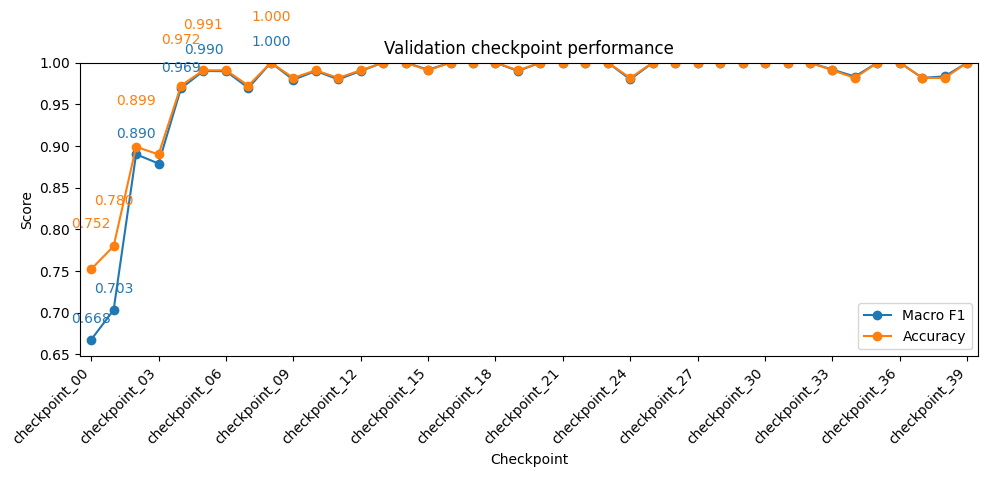

Seed 1234 best accuracy checkpoint: 8


In [32]:
best_by_seed = {seed: plot_validation_metrics(seed) for seed in SEEDS} if CONFIG['validation_fraction'] > 0 else {}
# if validation set, computes the best checkpoint per seed

In [33]:
def evaluate_test(epoch, seed):
    "Evaluate a checkpoint epoch on test."
    checkpoint_path = CHECKPOINT_ROOT / f"seed_{seed}" / f"checkpoint_{epoch:02d}.pt"
    device = torch.device(DEVICE)
    model = PointNet(CONFIG['feature_amount']).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)); model.eval()
    eval_samples = build_window_index(TEST_SPLIT_ROOT)
    eval_loader = DataLoader(RadHARDataset(eval_samples), batch_size=CONFIG['batch_size'])

    predictions, true_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            true_labels.append(labels)

    predictions, labels = torch.cat(predictions), torch.cat(true_labels)
    per_class_f1 = compute_f1(predictions, labels)
    test_macro_f1 = sum(per_class_f1) / len(per_class_f1)
    test_accuracy = (predictions == labels).float().mean().item()
    print(f'Seed {seed} | Test macro F1: {test_macro_f1:.4f}\nSeed {seed} | Test accuracy: {test_accuracy:.4f}')
    print({name: score for name, score in zip(ACTIVITY_CLASS_NAMES, per_class_f1)})
    return test_accuracy

In [ ]:
test_scores = {seed: evaluate_test(best_by_seed.get(seed, CONFIG['num_epochs'] - 1), seed) for seed in SEEDS}
# .get return the value if the key exsit, otherwise the fallback
print('Test scores:', test_scores)

Seed 1234 | Test macro F1: 0.9604
Seed 1234 | Test accuracy: 0.9592
{'boxing': 1.0, 'jack': 0.99581589958159, 'jump': 0.895397489539749, 'squats': 0.9874476987447699, 'walk': 0.9235880398671097}
Test scores: {1234: 0.9592476487159729}
